# 1. Setup — Environment & Dependencies

In [1]:
# Create an isolated environment (you know this pattern from your Docker experience —
# same idea, just Python-level instead of container-level)
!python -m venv yolo_env
!source yolo_env/bin/activate  # on Windows: yolo_env\Scripts\activate

!pip install ultralytics roboflow supervision opencv-python matplotlib albumentations

Error: Command '['/content/yolo_env/bin/python3', '-m', 'ensurepip', '--upgrade', '--default-pip']' returned non-zero exit status 1.
/bin/bash: line 1: yolo_env/bin/activate: No such file or directory
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.4/46.4 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.2/88.2 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.8/302.8 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 377.1/377.1 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.8/35.8 MB 34.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 39.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.3/144.3 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 3.2 MB/s eta 0:00:00
   ━━━━━━

In [2]:
# Download YOLOv12 nano pretrained weights (2.6M params — small, fast, good for a laptop/Colab GPU)
! wget https://github.com/ultralytics/assets/releases/download/v8.4.0/yolo12n.pt

--2026-09-10 03:58:23--  https://github.com/ultralytics/assets/releases/download/v8.4.0/yolo12n.pt
Resolving github.com (github.com)... 140.82.113.4
Connecting to github.com (github.com)|140.82.113.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/521807533/25ab588f-21ac-44b7-93dc-0defead21c92?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-09-10T04%3A40%3A24Z&rscd=attachment%3B+filename%3Dyolo12n.pt&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-09-10T03%3A40%3A22Z&ske=2026-09-10T04%3A40%3A24Z&sks=b&skv=2018-11-09&sig=H5a1FK6lsULQY5PEIU4DQ42PNvjp5Jgxjucp8UlqX50%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc4OTAxMzAwMywibmJmIjoxNzg5MDEyNzAzLCJwYXRoIjoicmVsZWFzZWFzc2V0cHJvZHVjdGlvbi5ibG9iLmNvcmUud

# 2. Load & Sanity-Check the Pretrained Model

In [3]:
from ultralytics import YOLO
model = YOLO('yolo12n.pt')
print(model.model)  # prints the architecture — worth skimming once so it's not a black box

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
DetectionModel(
  (model): Sequential(
    (0): Conv(
      (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (1): Conv(
      (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (2): C3k2(
      (cv1): Conv(
        (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=T

# 3. Download & Prepare the Dataset (Roboflow)

In [ ]:
# dataset.py
from roboflow import Roboflow
import os

# NOTE: don't leave a real API key hardcoded in a notebook you'll submit/share —
# use an environment variable instead, e.g.:
# rf = Roboflow(api_key=os.environ["ROBOFLOW_API_KEY"])
rf = Roboflow(api_key="OBOFLOW_API_KEY")  # from roboflow.com account settings

project = rf.workspace("nani-tmzf6").project("package-detection-5ozpr")
version = project.version(2)
dataset = version.download("yolov8")  # format name; YOLOv12 uses the same label format as v8/v11

project2 = rf.workspace("damaged-package").project("damaged-package")
version2 = project2.version(2)
dataset2 = version2.download("yolov8")

print(f"Dataset location: {dataset.location}")
print(f"Dataset2 location: {dataset2.location}")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to package-detection-2 in yolov8:: 100%|██████████| 4824/4824 [00:01<00:00, 3287.67it/s]

loading Roboflow workspace...


loading Roboflow project...



Extracting Dataset Version Zip to Damaged-package-2 in yolov8:: 100%|██████████| 670/670 [00:00<00:00, 2330.58it/s]

Dataset location: /content/package-detection-2
Dataset2 location: /content/Damaged-package-2


In [5]:
import yaml

with open(f'{dataset.location}/data.yaml') as f:
    data = yaml.safe_load(f)

# Keep this as the single source of truth for class names/order everywhere below,
# instead of re-typing ['damaged', 'no damaged'] by hand in later cells — if Roboflow's
# class order doesn't match what you assume, every downstream metric/label is silently wrong.
CLASS_NAMES = data['names']
print(CLASS_NAMES)


['damaged', 'no damaged']


In [6]:
import yaml

with open(f'{dataset2.location}/data.yaml') as f:
    data = yaml.safe_load(f)

# Keep this as the single source of truth for class names/order everywhere below,
# instead of re-typing ['damaged', 'no damaged'] by hand in later cells — if Roboflow's
# class order doesn't match what you assume, every downstream metric/label is silently wrong.
CLASS_NAMES = data['names']
print(CLASS_NAMES)


['Damaged', 'Destroyed', 'Intact']


In [7]:
import os

def remove_augmented_files(dataset_location, split='train'):
    img_dir = f'{dataset_location}/{split}/images'
    label_dir = f'{dataset_location}/{split}/labels'
    removed = 0

    for fname in os.listdir(img_dir):
        if '_aug' in fname:
            os.remove(os.path.join(img_dir, fname))
            removed += 1

    for fname in os.listdir(label_dir):
        if '_aug' in fname:
            os.remove(os.path.join(label_dir, fname))

    print(f"Removed {removed} augmented image/label pairs")
    return removed

remove_augmented_files(dataset.location)

Removed 0 augmented image/label pairs


0

## 3.1 Class Balance Check

In [8]:
import os
from collections import Counter

def check_class_balance(dataset_location, split='train'):
    label_dir = f'{dataset_location}/{split}/labels'
    counts = Counter()
    for fname in os.listdir(label_dir):
        if not fname.endswith('.txt'):
            continue
        with open(os.path.join(label_dir, fname)) as f:
            for line in f:
                cls = int(float(line.strip().split()[0]))  # normalize "0", "0.0" -> 0
                counts[cls] += 1
    print(f"{split} set box counts: {dict(counts)}")
    return counts
print("DataSet 1:")
check_class_balance(dataset.location, 'train')
check_class_balance(dataset.location, 'valid')
check_class_balance(dataset.location, 'test')
train_counts = check_class_balance(dataset.location, 'train')
minority_class = min(train_counts, key=train_counts.get)
print(f"Minority class id: {minority_class}")
print("###########################################")
print ("DataSet 2:")
check_class_balance(dataset2.location, 'train')
check_class_balance(dataset2.location, 'valid')
check_class_balance(dataset2.location, 'test')
train_counts = check_class_balance(dataset2.location, 'train')
minority_class = min(train_counts, key=train_counts.get)
print(f"Minority class id: {minority_class}")

DataSet 1:
train set box counts: {0: 1430, 1: 274}
valid set box counts: {0: 396, 1: 85}
test set box counts: {0: 225, 1: 27}
train set box counts: {0: 1430, 1: 274}
Minority class id: 1
###########################################
DataSet 2:
train set box counts: {1: 75, 2: 782, 0: 294}
valid set box counts: {0: 20, 1: 12, 2: 2}
test set box counts: {1: 5, 0: 16, 2: 38}
train set box counts: {1: 75, 2: 782, 0: 294}
Minority class id: 1


## Merging 2 Datasets

In [9]:
import shutil

def remap_and_merge_intact_only(new_dataset_location, target_location, split='train'):
    """Pull only the Intact-labeled images from the new dataset, remap them to
    class 1 ('no damaged'), and copy into the target dataset's matching split."""
    src_img_dir = f'{new_dataset_location}/{split}/images'
    src_lbl_dir = f'{new_dataset_location}/{split}/labels'
    dst_img_dir = f'{target_location}/{split}/images'
    dst_lbl_dir = f'{target_location}/{split}/labels'

    copied = 0
    for fname in os.listdir(src_lbl_dir):
        if not fname.endswith('.txt'):
            continue
        with open(os.path.join(src_lbl_dir, fname)) as f:
            lines = [l.split() for l in f if l.strip()]

        # keep only boxes that are class 2 (Intact) in the source dataset
        intact_lines = [l for l in lines if int(float(l[0])) == 2]
        if not intact_lines:
            continue  # skip images with no Intact boxes at all

        stem = fname.rsplit('.', 1)[0]
        for ext in ('.jpg', '.jpeg', '.png'):
            src_img = f'{src_img_dir}/{stem}{ext}'
            if os.path.exists(src_img):
                new_name = f'merged_{stem}{ext}'
                shutil.copy(src_img, f'{dst_img_dir}/{new_name}')
                with open(f'{dst_lbl_dir}/merged_{stem}.txt', 'w') as f:
                    for l in intact_lines:
                        # remap class 2 -> 1 ('no damaged'), keep original box coords
                        f.write(f"1 {' '.join(l[1:])}\n")
                copied += 1
                break

    print(f"[{split}] Copied {copied} real Intact images as 'no damaged'")
    return copied

# 1. remove old synthetic augmentation first
remove_augmented_files(dataset.location, 'train')

# 2. merge real intact images across all splits
for split in ('train', 'valid', 'test'):
    remap_and_merge_intact_only(dataset2.location, dataset.location, split)

# 3. confirm new balance
check_class_balance(dataset.location, 'train')
check_class_balance(dataset.location, 'valid')
check_class_balance(dataset.location, 'test')

Removed 0 augmented image/label pairs
[train] Copied 66 real Intact images as 'no damaged'
[valid] Copied 2 real Intact images as 'no damaged'
[test] Copied 4 real Intact images as 'no damaged'
train set box counts: {0: 1430, 1: 1056}
valid set box counts: {0: 396, 1: 87}
test set box counts: {0: 225, 1: 65}


Counter({0: 225, 1: 65})

## 3.3 Deleting duplicates

In [10]:
!pip install ImageHash

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 11.9 MB/s eta 0:00:00


In [11]:
# pip install imagehash
import imagehash
from PIL import Image
from collections import defaultdict

def find_near_duplicates(dataset_location, splits=('train', 'valid', 'test'), threshold=5):
    hashes = defaultdict(list)
    for split in splits:
        img_dir = f'{dataset_location}/{split}/images'
        if not os.path.isdir(img_dir):
            continue
        for fname in os.listdir(img_dir):
            try:
                h = imagehash.phash(Image.open(os.path.join(img_dir, fname)))
                hashes[h].append((split, fname))
            except Exception:
                continue

    # group hashes that are within `threshold` hamming distance of each other
    hash_list = list(hashes.keys())
    visited = set()
    near_dup_groups = []
    for i, h1 in enumerate(hash_list):
        if h1 in visited:
            continue
        group = list(hashes[h1])
        for h2 in hash_list[i+1:]:
            if h2 not in visited and (h1 - h2) <= threshold:
                group.extend(hashes[h2])
                visited.add(h2)
        if len({s for s, _ in group}) > 1:  # only care if it spans multiple splits
            near_dup_groups.append(group)
            visited.add(h1)

    print(f"Near-duplicate groups spanning splits: {len(near_dup_groups)}")
    for g in near_dup_groups[:10]:
        print("  ", g)
    return near_dup_groups

near_dups = find_near_duplicates(dataset.location)

# deletion — val/test are small and must stay clean, so they always win.
# Priority: test > valid > train. Whichever split has the lowest priority
# number in a group is kept; everything else in that group is removed.
SPLIT_PRIORITY = {'test': 0, 'valid': 1, 'train': 2}

def remove_near_duplicates(dataset_location, groups):
    removed = 0
    for group in groups:
        keep = min(group, key=lambda item: SPLIT_PRIORITY.get(item[0], 99))
        for split, fname in group:
            if (split, fname) == keep:
                continue
            for sub, ext in [('images', None), ('labels', '.txt')]:
                path = f'{dataset_location}/{split}/{sub}/{fname if not ext else fname.rsplit(".",1)[0]+ext}'
                if os.path.exists(path):
                    os.remove(path)
            removed += 1
    print(f"Removed {removed} near-duplicate files")
    return removed

remove_near_duplicates(dataset.location, near_dups)  # uncomment once you've reviewed the list

Near-duplicate groups spanning splits: 233
   [('train', 'images-114-_jpg.rf.9ff238d1600c77da67e371595baad86a.jpg'), ('test', 'images-5-_jpg.rf.a805956110b31e795ef54a007608fe82.jpg')]
   [('train', 'm_20211201223615_ztfgyvow_jpeg_jpg.rf.9c81ad1a3634711e10de0d1c9bf6b840.jpg'), ('test', 'm_20211201223615_ztfgyvow_jpeg_jpg.rf.4b017b70db7e01d27a9119cf2278d2a7.jpg')]
   [('train', 'Penyok-111-_jpg.rf.6409509a19946be7a449f3bf57ad8f87.jpg'), ('valid', 'Penyok-111-_jpg.rf.6953c8fc9aff3f9740abd729b0e88127.jpg')]
   [('train', 'images-22-_jpg.rf.d2fe2a5eff796f765ef71a1c6f1aeb42.jpg'), ('test', 'images-49-_jpg.rf.7b571ab35b0af6af9b622d0101214f05.jpg')]
   [('train', 'd96d8e9647b6a86f1a364cbb14b178b9_jpg.rf.074f1877412a0fc57ef1f739c7ea02a4.jpg'), ('valid', 'd96d8e9647b6a86f1a364cbb14b178b9_jpg.rf.301fde72cbf5e736f8dcd353caf064b3.jpg')]
   [('train', 'Penyok-37-_jpg.rf.2f9b1ca7abf59c3e31fb34c50f5a2427.jpg'), ('valid', 'Penyok-55-_jpg.rf.7c10cd4f1afff4bd2ef8d610909517ff.jpg')]
   [('train', 'istockp

335

## Respliting with a fixed ratio

In [12]:
import os
import shutil
import random
from collections import defaultdict

def pool_and_resplit(dataset_location, train_ratio=0.7, valid_ratio=0.15, seed=42):
    """Combine all images across current train/valid/test into one pool,
    then re-split with consistent class ratios in each split."""
    random.seed(seed)

    # 1. gather every image+label pair currently in the dataset, tagged by its classes
    all_items = []
    for split in ('train', 'valid', 'test'):
        img_dir = f'{dataset_location}/{split}/images'
        lbl_dir = f'{dataset_location}/{split}/labels'
        if not os.path.isdir(img_dir):
            continue
        for fname in os.listdir(img_dir):
            stem = fname.rsplit('.', 1)[0]
            lbl_path = f'{lbl_dir}/{stem}.txt'
            if not os.path.exists(lbl_path):
                continue
            with open(lbl_path) as f:
                classes = set(int(float(l.split()[0])) for l in f if l.strip())
            all_items.append((split, fname, stem, classes))

    print(f"Total pooled images: {len(all_items)}")

    # 2. stratify by whether the image contains class 1 ('no damaged'), so both
    #    splits get proportional representation of the minority-heavier class
    has_class1 = [item for item in all_items if 1 in item[3]]
    no_class1 = [item for item in all_items if 1 not in item[3]]
    random.shuffle(has_class1)
    random.shuffle(no_class1)

    def split_group(group):
        n = len(group)
        n_train = int(n * train_ratio)
        n_valid = int(n * valid_ratio)
        return group[:n_train], group[n_train:n_train+n_valid], group[n_train+n_valid:]

    train1, valid1, test1 = split_group(has_class1)
    train0, valid0, test0 = split_group(no_class1)

    new_assignment = {}
    for group, name in [(train1+train0, 'train'), (valid1+valid0, 'valid'), (test1+test0, 'test')]:
        for old_split, fname, stem, _ in group:
            new_assignment[(old_split, fname)] = (name, fname, stem)

    # 3. move files into a fresh directory structure
    out_base = f'{dataset_location}_resplit'
    for split in ('train', 'valid', 'test'):
        os.makedirs(f'{out_base}/{split}/images', exist_ok=True)
        os.makedirs(f'{out_base}/{split}/labels', exist_ok=True)

    for (old_split, fname), (new_split, fname2, stem) in new_assignment.items():
        src_img = f'{dataset_location}/{old_split}/images/{fname}'
        src_lbl = f'{dataset_location}/{old_split}/labels/{stem}.txt'
        shutil.copy(src_img, f'{out_base}/{new_split}/images/{fname}')
        shutil.copy(src_lbl, f'{out_base}/{new_split}/labels/{stem}.txt')

    print(f"Re-split dataset written to: {out_base}")
    return out_base

new_location = pool_and_resplit(dataset.location)
shutil.copy(f'{dataset.location}/data.yaml', f'{new_location}/data.yaml')

Total pooled images: 2143
Re-split dataset written to: /content/package-detection-2_resplit


'/content/package-detection-2_resplit/data.yaml'

In [13]:
import os
print(os.path.exists(f'{new_location}/data.yaml'))
check_class_balance(new_location, 'train')
check_class_balance(new_location, 'valid')
check_class_balance(new_location, 'test')

True
train set box counts: {0: 1220, 1: 920}
valid set box counts: {0: 259, 1: 95}
test set box counts: {0: 268, 1: 161}


Counter({0: 268, 1: 161})

## Corrupt/unreadable image detection

In [14]:
from PIL import Image

def find_corrupt_images(dataset_location, splits=('train', 'valid', 'test')):
    corrupt = []
    for split in splits:
        img_dir = f'{dataset_location}/{split}/images'
        if not os.path.isdir(img_dir):
            continue
        for fname in os.listdir(img_dir):
            path = os.path.join(img_dir, fname)
            try:
                if os.path.getsize(path) == 0:
                    raise ValueError("zero-byte file")
                img = Image.open(path)
                img.verify()  # checks file integrity without fully decoding
            except Exception as e:
                corrupt.append((split, fname, str(e)))

    print(f"Corrupt/unreadable images found: {len(corrupt)}")
    for split, fname, err in corrupt:
        print(f"  {split}/{fname}: {err}")
    return corrupt

corrupt_files = find_corrupt_images(new_location)

# --- deletion, commented out — uncomment only if len(corrupt_files) is small enough to sanity check ---
# for split, fname, _ in corrupt_files:
#     img_path = f'{dataset.location}/{split}/images/{fname}'
#     label_path = f'{dataset.location}/{split}/labels/{fname.rsplit(".",1)[0]}.txt'
#     for p in (img_path, label_path):
#         if os.path.exists(p):
#             os.remove(p)
# print(f"Removed {len(corrupt_files)} corrupt image/label pairs")

Corrupt/unreadable images found: 0


## Label sanity check

In [15]:
def find_bad_labels(dataset_location, splits=('train', 'valid', 'test')):
    bad = []
    for split in splits:
        img_dir = f'{dataset_location}/{split}/images'
        label_dir = f'{dataset_location}/{split}/labels'
        if not os.path.isdir(label_dir):
            continue

        img_files = {f.rsplit('.', 1)[0] for f in os.listdir(img_dir)}
        label_files = {f.rsplit('.', 1)[0] for f in os.listdir(label_dir) if f.endswith('.txt')}

        # orphaned labels — .txt with no matching image
        for stem in label_files - img_files:
            bad.append((split, f'{stem}.txt', 'orphaned label, no matching image'))

        # malformed boxes inside existing label files
        for fname in os.listdir(label_dir):
            if not fname.endswith('.txt'):
                continue
            fpath = os.path.join(label_dir, fname)
            with open(fpath) as f:
                for line_num, line in enumerate(f, 1):
                    parts = line.strip().split()
                    if not parts:
                        continue
                    if len(parts) != 5:
                        bad.append((split, fname, f'line {line_num}: wrong number of values'))
                        continue
                    cls, xc, yc, bw, bh = parts
                    xc, yc, bw, bh = map(float, (xc, yc, bw, bh))
                    if bw <= 0 or bh <= 0:
                        bad.append((split, fname, f'line {line_num}: zero/negative width or height'))
                    if not (0 <= xc <= 1 and 0 <= yc <= 1 and 0 <= bw <= 1 and 0 <= bh <= 1):
                        bad.append((split, fname, f'line {line_num}: coordinate out of 0-1 range'))

    print(f"Label issues found: {len(bad)}")
    for split, fname, reason in bad[:15]:
        print(f"  {split}/{fname}: {reason}")
    return bad

bad_labels = find_bad_labels(new_location)

# deletion — removes the whole label file (and its image) if any issue was found in it
def remove_bad_labels(dataset_location, bad_labels):
    to_remove = {(split, fname) for split, fname, _ in bad_labels}
    removed = 0
    for split, fname in to_remove:
        stem = fname.rsplit('.', 1)[0]
        label_path = f'{dataset_location}/{split}/labels/{fname}'
        for ext in ('.jpg', '.jpeg', '.png'):
            img_path = f'{dataset_location}/{split}/images/{stem}{ext}'
            if os.path.exists(img_path):
                os.remove(img_path)
                break
        if os.path.exists(label_path):
            os.remove(label_path)
        removed += 1
    print(f"Removed {removed} image/label pairs with bad labels")
    return removed

# remove_bad_labels(dataset.location, bad_labels)  # uncomment once reviewed

Label issues found: 0


In [16]:
check_class_balance(new_location, 'train')
check_class_balance(new_location, 'valid')
check_class_balance(new_location, 'test')

train set box counts: {0: 1220, 1: 920}
valid set box counts: {0: 259, 1: 95}
test set box counts: {0: 268, 1: 161}


Counter({0: 268, 1: 161})

# 4. Train YOLOv12

In [17]:
model = YOLO('yolo12n.pt')  # fresh weights — confirm this every time
results = model.train(
    data=f'{new_location}/data.yaml',
    epochs=80,
    imgsz=640,
    device='cuda',
    batch=16,
    workers=4,
    patience=15,
    close_mosaic=10,
    cls= 1.0,
    box=9.0,
    project='yolov12_package',
    name='package_detection'
)

Ultralytics 8.4.146 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=9.0, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=1.0, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/package-detection-2_resplit/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=80, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo12n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=package_detection, nbs=64, nm

In [18]:
best_weights_path = str(results.save_dir / 'weights' / 'best.pt')
print(f"Best weights at: {best_weights_path}")

Best weights at: /content/runs/detect/yolov12_package/package_detection/weights/best.pt


# 5. Evaluate — mAP, Precision, Recall, F1

In [19]:
import yaml
with open(f'{new_location}/data.yaml') as f:
    CLASS_NAMES = yaml.safe_load(f)['names']
print(CLASS_NAMES)

['damaged', 'no damaged']


In [20]:
import numpy as np

def evaluate_model(dataset_location, weights_path, class_names, split='test'):
    """Single source of truth for all reported metrics. Also derives, per class,
    the confidence threshold that ultralytics itself used to get the best F1 —
    later cells reuse this threshold instead of a hardcoded conf=0.25, so that
    any manual error-checking stays consistent with the numbers printed here."""
    from ultralytics import YOLO
    model = YOLO(weights_path)
    metrics = model.val(data=f'{dataset_location}/data.yaml', imgsz=640, split=split)

    print(f"{'='*50}")
    print(f"Overall mAP50: {metrics.box.map50:.4f}")
    print(f"Overall mAP50-95: {metrics.box.map:.4f}")
    print(f"{'='*50}\n")

    print("Per-class metrics:")
    for i, name in enumerate(class_names):
        p, r, f1, ap50 = metrics.box.p[i], metrics.box.r[i], metrics.box.f1[i], metrics.box.ap50[i]
        print(f"  {name}: P={p:.3f}  R={r:.3f}  F1={f1:.3f}  AP50={ap50:.3f}")

    mean_f1 = metrics.box.f1.mean()
    print(f"\nMean F1 across classes: {mean_f1:.4f}")

    # best-F1 confidence threshold per class, taken straight from the P/R/F1 curves
    # ultralytics computed internally — this is what recall/precision above are based on
    f1_curve, px = metrics.box.f1_curve, metrics.box.px
    best_conf = {i: float(px[np.argmax(f1_curve[i])]) for i in range(len(class_names))}
    print("\nBest-F1 confidence threshold per class (used later for error analysis):")
    for i, name in enumerate(class_names):
        print(f"  {name}: conf={best_conf[i]:.3f}")

    return metrics, best_conf

metrics, best_conf_per_class = evaluate_model(new_location, best_weights_path, CLASS_NAMES, split='test')

Ultralytics 8.4.146 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv12n summary (fused): 159 layers, 2,557,118 parameters, 0 gradients, 7.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1210.9±365.9 MB/s, size: 31.7 KB)
val: Scanning /content/package-detection-2_resplit/test/labels... 324 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 324/324 2.2Kit/s 0.1s
val: New cache created: /content/package-detection-2_resplit/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 21/21 4.5it/s 4.7s
                   all        324        429      0.817      0.773      0.822      0.702
               damaged        261        268      0.946      0.944      0.975      0.924
            no damaged         64        161      0.688      0.602      0.669      0.479
Speed: 1.9ms preprocess, 6.4ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to /content/runs/detect/val
Overall

## 5.1 Confusion Matrix

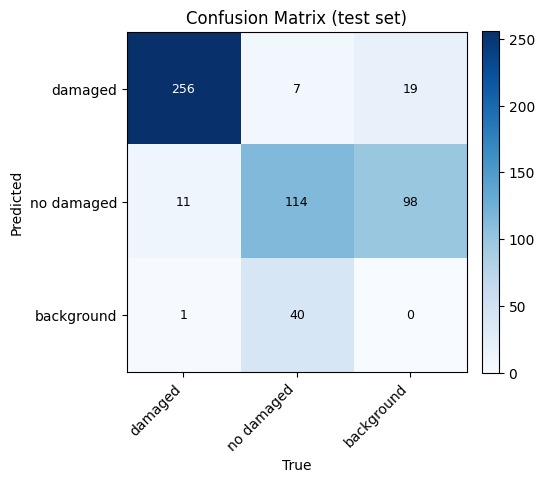

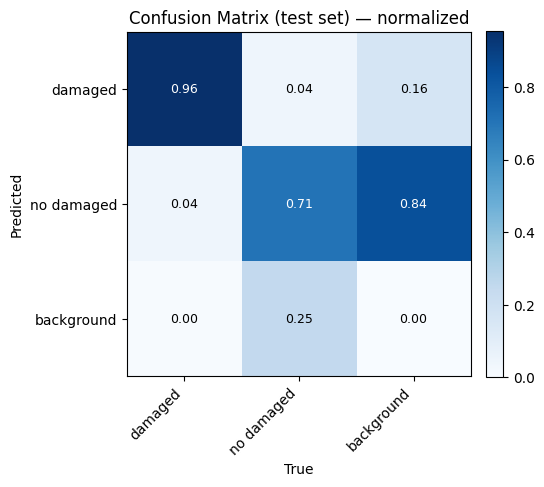

Raw counts (rows = predicted class, columns = true class, last row/col = background):
[[        256           7          19]
 [         11         114          98]
 [          1          40           0]]


In [21]:
import matplotlib.pyplot as plt

def plot_confusion_matrix(metrics, class_names, normalize=False):
    """Ultralytics' ConfusionMatrix stores matrix[predicted_idx, true_idx], with an
    extra final row/col for 'background' (missed detections / spurious detections
    with no matching ground truth). We plot it directly rather than reconstructing
    it from predict() calls, so it's guaranteed to match metrics.box.p/r above."""
    cm = metrics.confusion_matrix.matrix.copy()
    labels = list(class_names) + ['background']

    if normalize:
        col_sums = cm.sum(axis=0, keepdims=True)
        col_sums[col_sums == 0] = 1
        cm = cm / col_sums

    fig, ax = plt.subplots(figsize=(5.5, 5))
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
    ax.set_xlabel('True'); ax.set_ylabel('Predicted')
    ax.set_title('Confusion Matrix (test set)' + (' — normalized' if normalize else ''))

    vmax = cm.max() if cm.max() > 0 else 1
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            val = cm[i, j]
            text = f"{val:.2f}" if normalize else f"{int(val)}"
            ax.text(j, i, text, ha='center', va='center',
                     color='white' if val > vmax / 2 else 'black', fontsize=9)

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(metrics, CLASS_NAMES, normalize=False)
plot_confusion_matrix(metrics, CLASS_NAMES, normalize=True)

print("Raw counts (rows = predicted class, columns = true class, last row/col = background):")
print(metrics.confusion_matrix.matrix)


## 5.2 Training Curves — Accuracy (mAP) & Loss

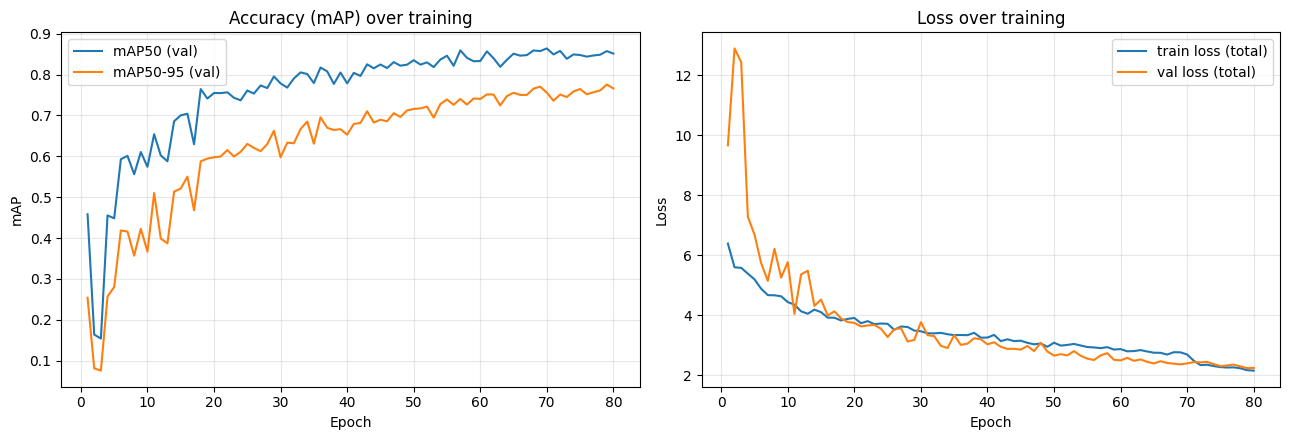

Final epoch (80):
  mAP50      = 0.8515
  mAP50-95   = 0.7663
  Train loss = 2.1567  (box=0.4434, cls=0.6635, dfl=1.0497)
  Val loss   = 2.2479  (box=0.4650, cls=0.8453, dfl=0.9376)


In [22]:
import pandas as pd
import matplotlib.pyplot as plt

results_csv = f'{results.save_dir}/results.csv'
df = pd.read_csv(results_csv)
df.columns = df.columns.str.strip()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Object detection has no single "accuracy" metric the way classification does —
# mAP50 (and mAP50-95) is the closest equivalent, so that's what we plot here.
axes[0].plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP50 (val)')
axes[0].plot(df['epoch'], df['metrics/mAP50-95(B)'], label='mAP50-95 (val)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('mAP')
axes[0].set_title('Accuracy (mAP) over training')
axes[0].legend(); axes[0].grid(alpha=0.3)

train_loss = df['train/box_loss'] + df['train/cls_loss'] + df['train/dfl_loss']
val_loss = df['val/box_loss'] + df['val/cls_loss'] + df['val/dfl_loss']
axes[1].plot(df['epoch'], train_loss, label='train loss (total)')
axes[1].plot(df['epoch'], val_loss, label='val loss (total)')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].set_title('Loss over training')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Final (last-epoch) values, printed explicitly as requested
last = df.iloc[-1]
print(f"Final epoch ({int(last['epoch'])}):")
print(f"  mAP50      = {last['metrics/mAP50(B)']:.4f}")
print(f"  mAP50-95   = {last['metrics/mAP50-95(B)']:.4f}")
print(f"  Train loss = {train_loss.iloc[-1]:.4f}  "
      f"(box={last['train/box_loss']:.4f}, cls={last['train/cls_loss']:.4f}, dfl={last['train/dfl_loss']:.4f})")
print(f"  Val loss   = {val_loss.iloc[-1]:.4f}  "
      f"(box={last['val/box_loss']:.4f}, cls={last['val/cls_loss']:.4f}, dfl={last['val/dfl_loss']:.4f})")


## 5.3 Train vs Val — Overfitting Check (per class)

In [23]:
# Evaluating on the *train* split isn't a real performance number — the model was
# directly trained on these exact images (plus augmented near-duplicates of them),
# so this is a memorization check, not a generalization check. It's only useful
# as a *gap* against val/test, which is what we print below.
train_metrics = model.val(data=f'{new_location}/data.yaml', split='train')
val_metrics = model.val(data=f'{new_location}/data.yaml', split='val')

print("Per-class AP50 — train vs val (large gap = overfitting on that class):")
for i, name in enumerate(CLASS_NAMES):
    train_ap = train_metrics.box.ap50[i]
    val_ap = val_metrics.box.ap50[i]
    gap = train_ap - val_ap
    flag = "  <-- possible overfitting" if gap > 0.05 else ""
    print(f"  {name}: train={train_ap:.3f}  val={val_ap:.3f}  gap={gap:+.3f}{flag}")


Ultralytics 8.4.146 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv12n summary (fused): 159 layers, 2,557,118 parameters, 0 gradients, 7.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1532.3±601.9 MB/s, size: 44.5 KB)
val: Scanning /content/package-detection-2_resplit/train/labels.cache... 1499 images, 8 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1499/1499 449.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 94/94 5.4it/s 17.4s
                   all       1499       2140       0.91      0.887       0.93      0.802
               damaged       1206       1220      0.983       0.99      0.994       0.96
            no damaged        291        920      0.837      0.784      0.866      0.644
Speed: 1.2ms preprocess, 5.9ms inference, 0.0ms loss, 1.0ms postprocess per image
Results saved to /content/runs/detect/val-2
Ultralytics 8.4.146 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T

# 6. Error Analysis (IoU-Matched)

The previous version of this section checked only whether a class *appeared
anywhere* in an image's predictions at a fixed `conf=0.25`. That doesn't match
how `Overall mAP50` and per-class `P`/`R` above are actually computed — those
use box-level IoU matching at whatever confidence threshold gives each class
its best F1. As a result, the old "N images with a missed detection" counts
didn't line up with what the reported recall/precision implied.

This version fixes that: it matches predicted boxes to ground-truth boxes by
IoU (like `val()` does internally) and uses the same per-class confidence
threshold recovered in Section 5, so the counts below are consistent with the
metrics printed above.

In [24]:
import torch
from pathlib import Path
from ultralytics.utils.metrics import box_iou


def load_yolo_labels(label_path, img_w, img_h):
    """Read a YOLO .txt label file, return (boxes_xyxy, classes)."""
    boxes, classes = [], []
    if not os.path.exists(label_path):
        return boxes, classes
    with open(label_path) as f:
        for line in f:
            if not line.strip():
                continue
            cls, xc, yc, w, h = map(float, line.split())
            xc, yc, w, h = xc * img_w, yc * img_h, w * img_w, h * img_h
            boxes.append([xc - w / 2, yc - h / 2, xc + w / 2, yc + h / 2])
            classes.append(int(cls))
    return boxes, classes


def is_match(pred_boxes, pred_classes, gt_boxes, gt_classes, target_cls, iou_thresh=0.5):
    """True/False = target_cls is/isn't correctly localized in this image.
    None = target_cls isn't in the ground truth at all (not relevant here)."""
    gt_idx = [i for i, c in enumerate(gt_classes) if c == target_cls]
    pred_idx = [i for i, c in enumerate(pred_classes) if c == target_cls]
    if not gt_idx:
        return None
    if not pred_idx:
        return False
    ious = box_iou(torch.tensor(pred_boxes)[pred_idx], torch.tensor(gt_boxes)[gt_idx])
    return bool((ious.max(dim=0).values >= iou_thresh).any())


def find_matched_errors(dataset_location, weights_path, class_thresholds, class_names,
                         split='test', iou_thresh=0.5):
    """Returns:
      false_negatives: list of (image_path, missed_class_id) — GT had the class, nothing matched it
      false_positives: list of (image_path, predicted_class_id) — a kept prediction matched no GT box
    Both use the per-class best-F1 confidence threshold, not a single fixed value."""
    from ultralytics import YOLO
    model = YOLO(weights_path)

    img_dir = Path(dataset_location) / split / 'images'
    label_dir = Path(dataset_location) / split / 'labels'
    min_conf = min(class_thresholds.values())

    false_negatives, false_positives = [], []

    for img_path in sorted(img_dir.glob('*')):
        if img_path.suffix.lower() not in ('.jpg', '.jpeg', '.png'):
            continue
        label_path = label_dir / (img_path.stem + '.txt')

        result = model.predict(str(img_path), conf=min_conf, verbose=False)[0]
        img_h, img_w = result.orig_shape
        gt_boxes, gt_classes = load_yolo_labels(label_path, img_w, img_h)

        raw_boxes = result.boxes.xyxy.cpu().numpy().tolist()
        raw_classes = result.boxes.cls.cpu().numpy().astype(int).tolist()
        raw_confs = result.boxes.conf.cpu().numpy().tolist()

        # keep only predictions that clear THEIR OWN class's best-F1 threshold
        pred_boxes, pred_classes = [], []
        for b, c, conf in zip(raw_boxes, raw_classes, raw_confs):
            if conf >= class_thresholds.get(c, min_conf):
                pred_boxes.append(b)
                pred_classes.append(c)

        for cls_id in class_thresholds:
            if is_match(pred_boxes, pred_classes, gt_boxes, gt_classes, cls_id, iou_thresh) is False:
                false_negatives.append((str(img_path), cls_id))

        for pb, pc in zip(pred_boxes, pred_classes):
            gt_same_cls = [g for g, gc in zip(gt_boxes, gt_classes) if gc == pc]
            if not gt_same_cls:
                false_positives.append((str(img_path), pc))
                continue
            ious = box_iou(torch.tensor([pb]), torch.tensor(gt_same_cls))
            if ious.max().item() < iou_thresh:
                false_positives.append((str(img_path), pc))

    return false_negatives, false_positives


false_negatives, false_positives = find_matched_errors(
    new_location, best_weights_path, best_conf_per_class, CLASS_NAMES, split='test'
)

print(f"False negatives (missed detections): {len(false_negatives)}")
for name_i in range(len(CLASS_NAMES)):
    n = sum(1 for _, c in false_negatives if c == name_i)
    print(f"  {CLASS_NAMES[name_i]}: {n}")

print(f"\nFalse positives (predicted, no matching ground truth): {len(false_positives)}")
for name_i in range(len(CLASS_NAMES)):
    n = sum(1 for _, c in false_positives if c == name_i)
    print(f"  {CLASS_NAMES[name_i]}: {n}")

# Sanity cross-check against the recall/precision printed in Section 5
test_counts = check_class_balance(new_location, 'test')
print("\nCross-check against Section 5 metrics:")
for i, name in enumerate(CLASS_NAMES):
    expected_missed = round((1 - metrics.box.r[i]) * test_counts[i])
    actual_missed = sum(1 for _, c in false_negatives if c == i)
    print(f"  {name}: recall implies ~{expected_missed} missed instances, found {actual_missed} here")


False negatives (missed detections): 25
  damaged: 16
  no damaged: 9

False positives (predicted, no matching ground truth): 53
  damaged: 10
  no damaged: 43
test set box counts: {0: 268, 1: 161}

Cross-check against Section 5 metrics:
  damaged: recall implies ~15 missed instances, found 16 here
  no damaged: recall implies ~64 missed instances, found 9 here


## 6.1 Visualize Misclassified Images

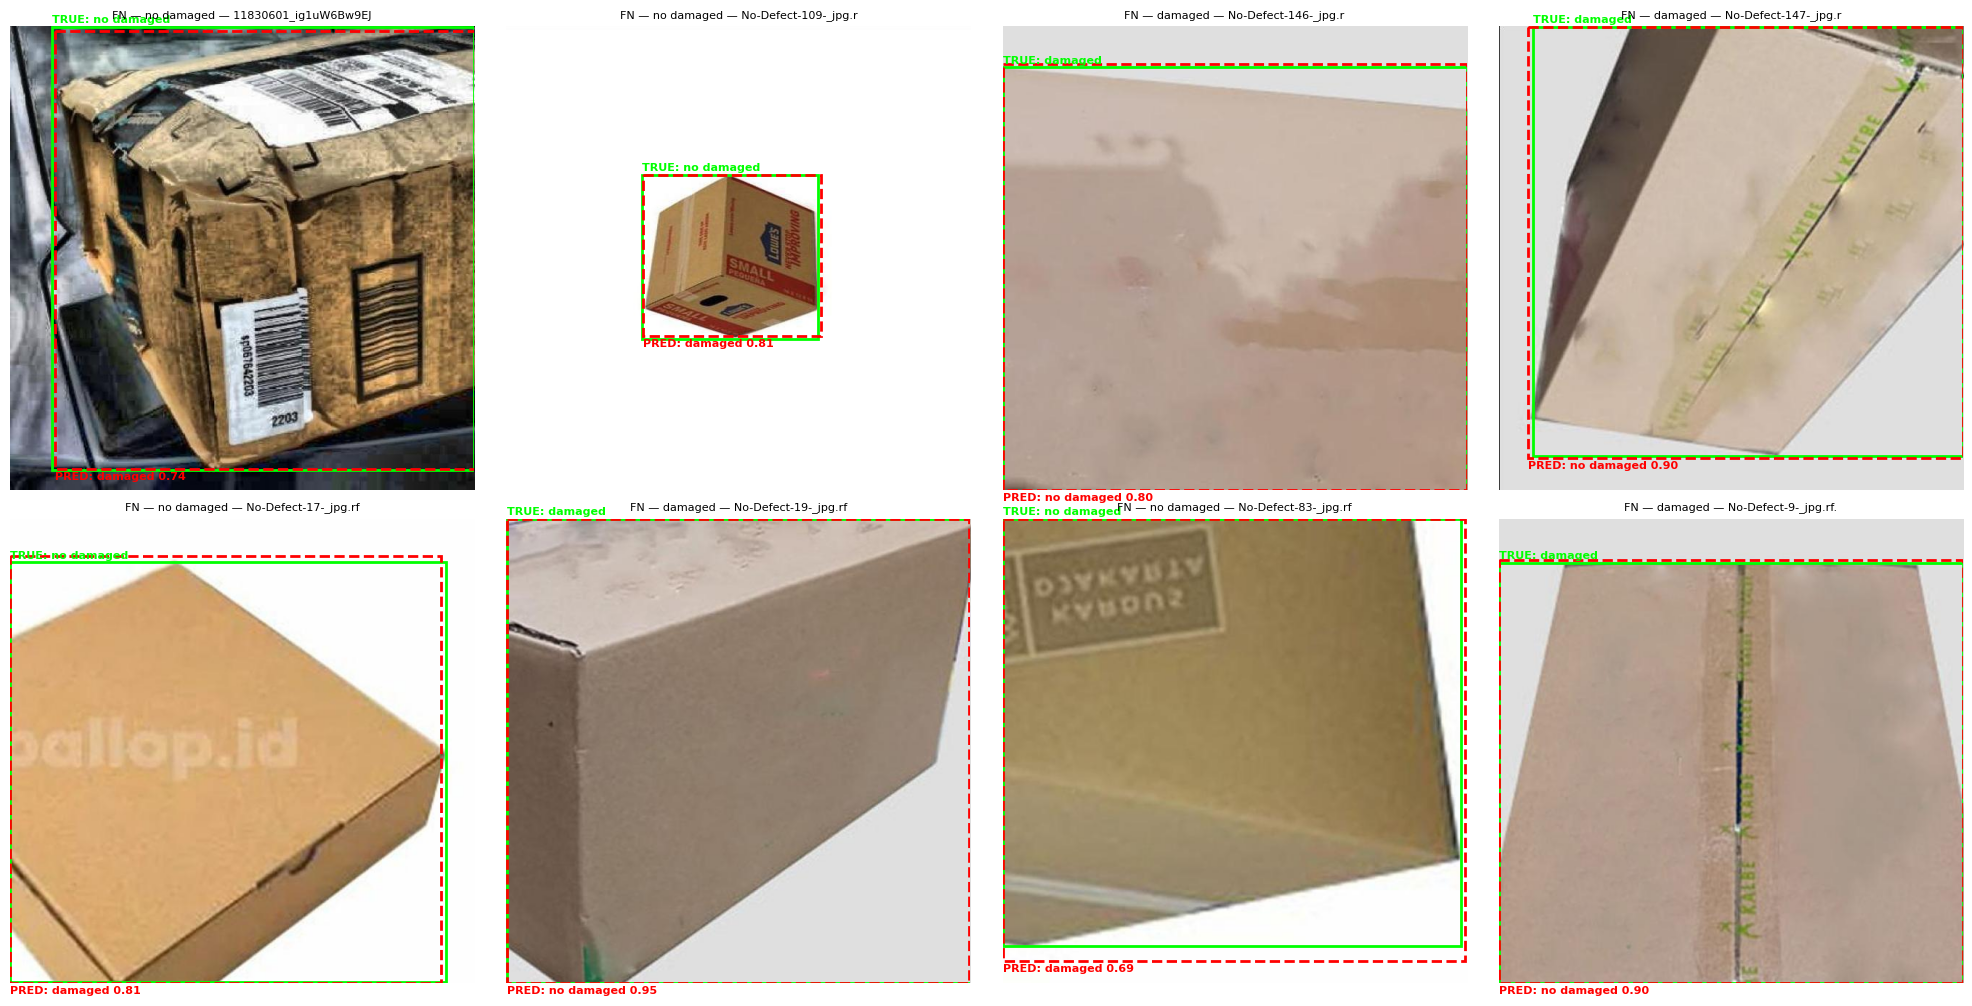

In [25]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image


def show_mistakes_with_boxes(dataset_location, weights_path, mistake_entries, class_names,
                              split='test', max_images=8):
    """mistake_entries: list of (image_path, class_id, kind) where kind is 'FN' or 'FP'."""
    from ultralytics import YOLO
    model = YOLO(weights_path)

    entries = mistake_entries[:max_images]
    n = len(entries)
    if n == 0:
        print("No images to show")
        return

    cols = min(4, n)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
    axes = axes.flatten() if n > 1 else [axes]

    for ax, (img_path, cls_id, kind) in zip(axes, entries):
        img_path = Path(img_path)
        img = Image.open(img_path)
        w, h = img.size
        ax.imshow(img)

        label_path = Path(dataset_location) / split / 'labels' / (img_path.stem + '.txt')
        if label_path.exists():
            with open(label_path) as f:
                for line in f:
                    if not line.strip():
                        continue
                    parts = line.split()
                    cls, xc, yc, bw, bh = int(parts[0]), *map(float, parts[1:])
                    x1, y1 = (xc - bw / 2) * w, (yc - bh / 2) * h
                    rect = patches.Rectangle((x1, y1), bw * w, bh * h, linewidth=2,
                                              edgecolor='lime', facecolor='none')
                    ax.add_patch(rect)
                    ax.text(x1, y1 - 5, f"TRUE: {class_names[cls]}", color='lime', fontsize=8, weight='bold')

        result = model.predict(str(img_path), conf=best_conf_per_class[cls_id], verbose=False)[0]
        for box in result.boxes:
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            cls = int(box.cls[0].item())
            conf = box.conf[0].item()
            rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=2,
                                      edgecolor='red', facecolor='none', linestyle='--')
            ax.add_patch(rect)
            ax.text(x1, y2 + 15, f"PRED: {class_names[cls]} {conf:.2f}", color='red', fontsize=8, weight='bold')

        ax.set_title(f"{kind} — {class_names[cls_id]} — {img_path.name[:20]}", fontsize=8)
        ax.axis('off')

    for ax in axes[n:]:
        ax.axis('off')

    plt.tight_layout()
    plt.show()


mistake_entries = (
    [(p, c, 'FN') for p, c in false_negatives] +
    [(p, c, 'FP') for p, c in false_positives]
)
show_mistakes_with_boxes(new_location, best_weights_path, mistake_entries, CLASS_NAMES)


# 7. Test on Sample Images

This step was listed in your task list but wasn't in the original notebook as a standalone check (your error-analysis cells above are a more advanced version of it). Added here as a quick, literal 'run inference on a handful of images and look at it' cell.

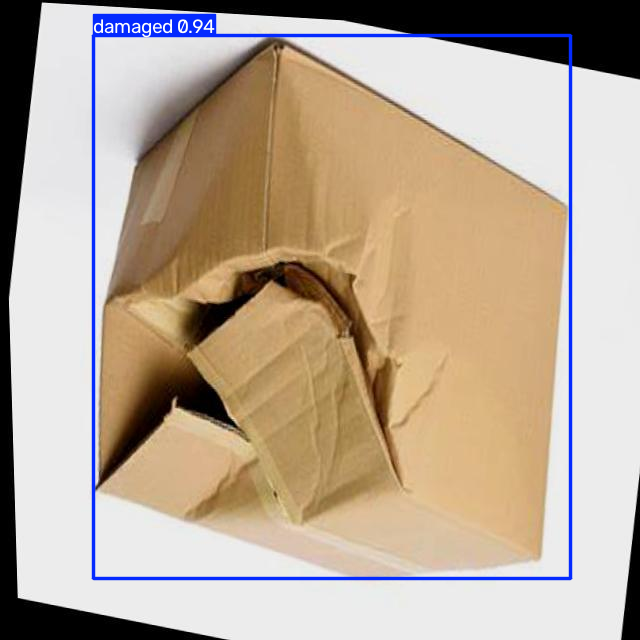

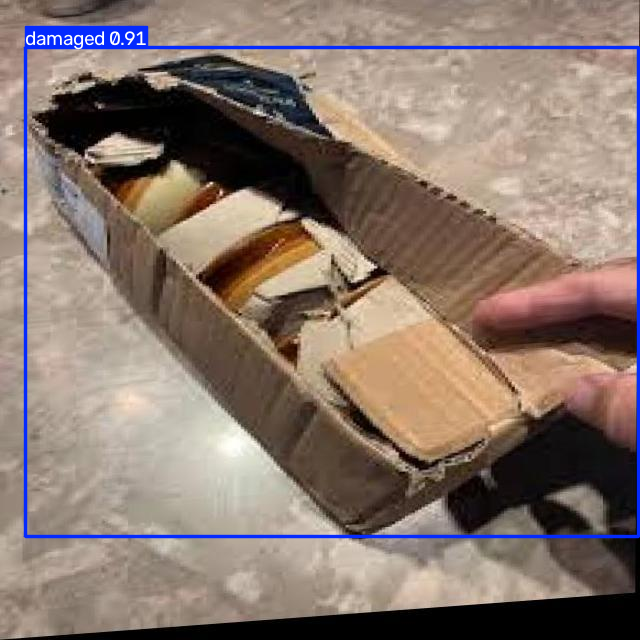

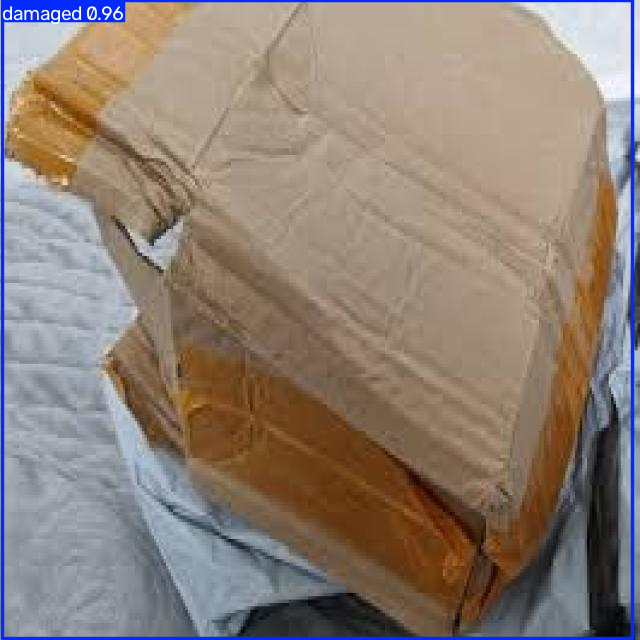

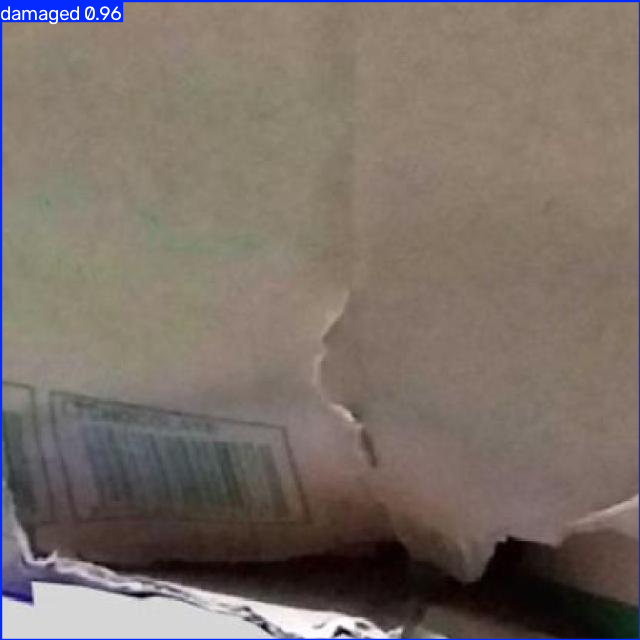

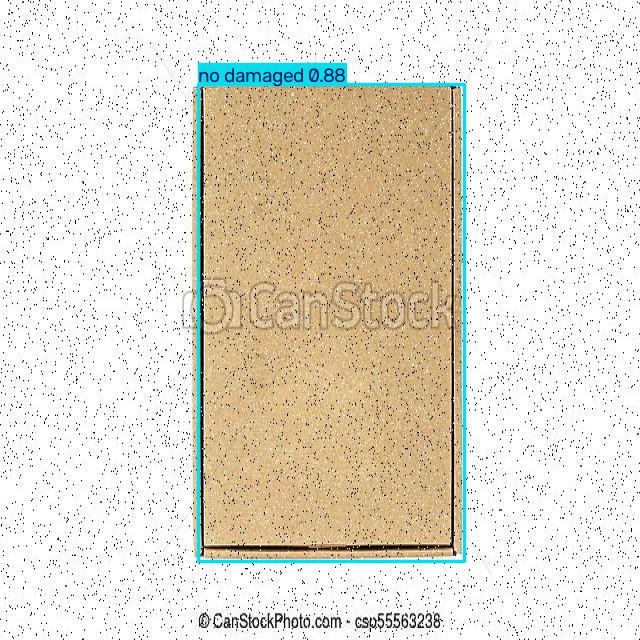

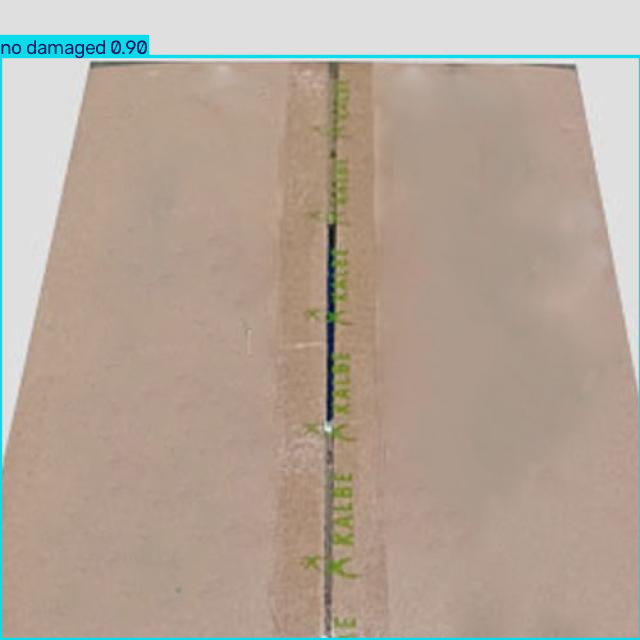

In [26]:
import random

sample_dir = f'{new_location}/test/images'
sample_files = random.sample(os.listdir(sample_dir), k=min(6, len(os.listdir(sample_dir))))

best_model = YOLO(best_weights_path)
for fname in sample_files:
    result = best_model.predict(source=os.path.join(sample_dir, fname), conf=0.25, verbose=False)[0]
    result.show()  # opens/plots the image with predicted boxes drawn on it

# 8. Stock Report

In [27]:
def get_stock_count(weights_path, image_folder, conf_threshold=0.417, iou_threshold=0.5):
    from ultralytics import YOLO
    import json
    model = YOLO(weights_path)
    results = model.predict(source=image_folder, conf=conf_threshold, iou=iou_threshold, verbose=False)

    counts = {'damaged': 0, 'no damaged': 0}
    detections = []

    for result in results:
        img_h, img_w = result.orig_shape
        for box in result.boxes:
            cls_id = int(box.cls[0].item())
            cls_name = result.names[cls_id]
            counts[cls_name] += 1
            detections.append({'image': result.path, 'class': cls_name,
                                'confidence': round(box.conf[0].item(), 3)})

    report = {'total_damaged': counts['damaged'], 'total_no_damaged': counts['no damaged'],
              'detections': detections}
    with open('stock_report.json', 'w') as f:
        json.dump(report, f, indent=2)
    print(f"Damaged: {counts['damaged']}, No damaged: {counts['no damaged']}")
    return report

report = get_stock_count(best_weights_path, f'{new_location}/test/images')

Damaged: 265, No damaged: 158


# 9. Export Model for Deployment

This was task #6 in your role but was missing from the original notebook — added here. ONNX is the most portable choice if the model will be served behind an API; TorchScript is a fine alternative if the serving stack is pure PyTorch.

In [28]:
from ultralytics import YOLO

best_model = YOLO(best_weights_path)

# ONNX — most portable for deployment (works with ONNX Runtime, many serving frameworks)
onnx_path = best_model.export(format='onnx', imgsz=640, simplify=True)
print(f"Exported ONNX model to: {onnx_path}")

# TorchScript — alternative if you're deploying inside a pure PyTorch service
torchscript_path = best_model.export(format='torchscript', imgsz=640)
print(f"Exported TorchScript model to: {torchscript_path}")

Ultralytics 8.4.146 🚀 Python-3.13.15 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino
YOLOv12n summary (fused): 159 layers, 2,557,118 parameters, 0 gradients, 7.3 GFLOPs

PyTorch: starting from '/content/runs/detect/yolov12_package/package_detection/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 6, 8400) (5.3 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxruntime', 'onnxslim>=0.1.82'] not found, attempting AutoUpdate...
Using Python 3.13.15 environment at: /usr
Resolved 12 packages in 298ms
Prepared 4 packages in 934ms
Installed 4 packages in 261ms
 + colorama==0.4.6
 + onnx==1.22.0
 + onnxruntime==1.29.0
 + onnxslim==0.1.96

requirements: AutoUpdate success ✅ 1.9s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.22.0 

In [29]:
empty = sum(1 for f in os.listdir(f'{new_location}/train/labels')
            if os.path.getsize(f'{new_location}/train/labels/{f}') == 0)
print(f"Background-only training images: {empty}")

Background-only training images: 8
